# UCCSD–VQE for the Pairing Hamiltonian — Trotterised & scalable

**Adding Trotterisation, flexible particle number / level number, and a scan to $k=8$**

This notebook extends `pairing_uccsd_vqe.ipynb` in three ways, following the
Trotterised UCCSD implementation of `qdresrefinement_vqe_K12_with_UCCSD.ipynb`:

1. **Trotterisation.** The UCCSD unitary is applied as a *product* of elementary
   factors $\prod_\mu e^{\theta_\mu(\hat\tau_\mu-\hat\tau_\mu^\dagger)}$ (first-order
   Trotter, singles then doubles).  Each factor is a set of disjoint $2\times2$
   rotations on the Fock basis, applied by vectorised indexing — no dense matrix
   exponential, no $2^{2k}\times2^{2k}$ Hamiltonian.

2. **Flexible $N$ and $k$.**  The number of fermions $N$ (an even number of paired
   particles) and the number of doubly-degenerate levels $k$ are both free
   parameters.  The Hartree–Fock reference fills the lowest $N/2$ levels.

3. **Scaling to $k=8$.**  With the Fock-basis (bitstring) representation we reach
   $k=8$ levels = **16 qubits**, working inside the fixed-$N$ sector so the cost is set
   by $\binom{2k}{N}$ rather than $2^{2k}$.  Throughout we keep four particles as the
   running example but vary $N$ as well.

Every calculation is benchmarked against **full configuration interaction (FCI)** —
the exact diagonalisation of the Hamiltonian in the $N$-particle sector — and against
the classical **coupled-cluster doubles (CCD)** solver of `week47.ipynb`.

---
## 1  The pairing Hamiltonian for general $(k, N)$

We keep the *Lecture Notes in Physics* **936** constant-pairing Hamiltonian,

$$
\hat H \;=\; \delta\sum_{p=0}^{k-1} p \sum_{\sigma=\uparrow,\downarrow}
              \hat a^{\dagger}_{p\sigma}\hat a_{p\sigma}
       \;-\;\frac{g}{2}\sum_{p,q=0}^{k-1}
              \hat a^{\dagger}_{p\uparrow}\hat a^{\dagger}_{p\downarrow}
              \hat a_{q\downarrow}\hat a_{q\uparrow},
$$

now with $k$ doubly-degenerate levels and $N$ fermions ($N$ even, $P=N/2$ pairs).  Level
$p$ has energy $\delta p$; we set $\delta=1$.  The **Hartree–Fock reference** fills the
$P$ lowest levels,
$$
|\Phi_{\rm HF}\rangle=\Big(\prod_{p=0}^{P-1}\hat A^{\dagger}_p\Big)|0\rangle,
\qquad \hat A^{\dagger}_p=\hat a^{\dagger}_{p\uparrow}\hat a^{\dagger}_{p\downarrow},
$$
with energy
$$
E_{\rm HF}(N,g)=2\delta\sum_{p=0}^{P-1}p-\frac{g}{2}P
            =\delta\,P(P-1)-\frac{g}{2}P .
$$
For $N=4$ ($P=2$) this is the familiar $E_{\rm HF}=2\delta-g$.

Both terms conserve **seniority** (the number of unpaired fermions); the attractive
pairing force keeps the ground state in the no-broken-pair sector, so the full
$N$-particle FCI ground state coincides with the seniority-zero result.

### Qubit / Fock-basis encoding

Each spin-orbital is one qubit; with $k$ levels there are $2k$ qubits ordered as
$\text{qubit}=2p+\sigma$ ($\sigma=0\!\uparrow,\,1\!\downarrow$).  A Slater determinant
is an integer bitstring, and fermionic operators act through the Jordan–Wigner sign.
Because $\hat H$ and the UCCSD generators conserve $N$, we never leave the
$N$-particle sector — a space of dimension $\binom{2k}{N}$ (e.g. $\binom{16}{4}=1820$
for $k=8,N=4$), far smaller than the full $2^{16}$ Fock space.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time
from itertools import combinations
from scipy.sparse import csr_matrix
from scipy.sparse.linalg import eigsh
from scipy.optimize import minimize

DELTA = 1.0          # single-particle level spacing

# ----- bitstring (Fock-basis) helpers: n = number of qubits = 2k -----
def _bit(s, j, n):  return (s >> (n-1-j)) & 1          # is qubit j occupied in state s?
def _flip(s, j, n): return s ^ (1 << (n-1-j))          # create/annihilate at qubit j
def _jw_sign(s, j, n):
    """Jordan-Wigner sign: (-1)^(occupied qubits before position j)."""
    c = 0
    for q in range(j):
        if (s >> (n-1-q)) & 1: c += 1
    return 1 - 2*(c % 2)

def build_sector(k, N):
    """Computational-basis states of the N-particle sector on 2k qubits."""
    nq = 2*k
    states = sorted(sum(1 << (nq-1-j) for j in c) for c in combinations(range(nq), N))
    index  = {s: i for i, s in enumerate(states)}
    return nq, states, index

def E_HF(N, g, delta=DELTA):
    P = N // 2
    return 2.0*delta*sum(range(P)) - 0.5*g*P

print("Sector dimensions  dim = C(2k, N):")
for k in (2,3,4,5,6,7,8):
    print(f"  k={k:2d} ({2*k:2d} qubits): "
          + "  ".join(f"N={N}:{len(list(combinations(range(2*k),N))):5d}" for N in (2,4,6)))

Sector dimensions  dim = C(2k, N):
  k= 2 ( 4 qubits): N=2:    6  N=4:    1  N=6:    0
  k= 3 ( 6 qubits): N=2:   15  N=4:   15  N=6:    1
  k= 4 ( 8 qubits): N=2:   28  N=4:   70  N=6:   28
  k= 5 (10 qubits): N=2:   45  N=4:  210  N=6:  210
  k= 6 (12 qubits): N=2:   66  N=4:  495  N=6:  924
  k= 7 (14 qubits): N=2:   91  N=4: 1001  N=6: 3003
  k= 8 (16 qubits): N=2:  120  N=4: 1820  N=6: 8008


---
## 2  Sparse Hamiltonian and full FCI

We build $\hat H$ as a sparse matrix directly in the $N$-particle sector by letting the
pair operators act on each bitstring determinant, and obtain the **FCI** ground state by
diagonalising it (dense for small sectors, Lanczos `eigsh` for large ones).

In [2]:
def H_pairing_sparse(k, g, N, states, index, delta=DELTA):
    """Pairing Hamiltonian as a sparse matrix in the N-particle sector."""
    nq = 2*k; M = len(states); gh = -0.5*g
    rows, cols, vals = [], [], []
    for I in states:
        a = index[I]
        rows.append(a); cols.append(a)
        vals.append(sum(delta*(j//2) for j in range(nq) if _bit(I, j, nq)))   # one-body
        for p in range(k):                                                    # -g/2 A_p^dag A_q
            for q in range(k):
                r0, r1 = 2*q, 2*q+1;  c0, c1 = 2*p, 2*p+1
                if not _bit(I, r0, nq): continue
                s1 = _jw_sign(I, r0, nq);  t = _flip(I, r0, nq)
                if not _bit(t, r1, nq): continue
                s2 = _jw_sign(t, r1, nq);  t = _flip(t, r1, nq)
                if _bit(t, c1, nq): continue
                s3 = _jw_sign(t, c1, nq);  t = _flip(t, c1, nq)
                if _bit(t, c0, nq): continue
                s4 = _jw_sign(t, c0, nq);  J = _flip(t, c0, nq)
                rows.append(index[J]); cols.append(a); vals.append(gh*s1*s2*s3*s4)
    H = csr_matrix((vals, (rows, cols)), shape=(M, M))
    return (H + H.T)*0.5

def fci_ground(H):
    """Lowest eigenvalue of H (dense for small sectors, Lanczos otherwise)."""
    M = H.shape[0]
    if M == 1:    return float(H[0, 0])
    if M <= 1500: return float(np.linalg.eigvalsh(H.toarray())[0])
    return float(eigsh(H, k=1, which='SA', maxiter=5000)[0][0])

# Cross-check: seniority-zero (pair-space) exact diagonalisation, dim C(k, P)
def pairing_seniority0(k, g, N, delta=DELTA):
    P = N//2
    basis = list(combinations(range(k), P)); idx = {s:i for i,s in enumerate(basis)}
    H = np.zeros((len(basis), len(basis)))
    for i, occ in enumerate(basis):
        H[i,i] = 2.0*delta*sum(occ) - 0.5*g*P
        so = set(occ)
        for pout in occ:
            for pin in range(k):
                if pin in so: continue
                H[i, idx[tuple(sorted(so-{pout}|{pin}))]] += -0.5*g
    return np.linalg.eigvalsh(H)[0]

print("Full FCI (N-sector) vs seniority-zero exact diagonalisation,  N=4, g=1")
print("="*68)
for k in (2,3,4,5,6,7,8):
    nq, states, index = build_sector(k, 4)
    H = H_pairing_sparse(k, 1.0, 4, states, index)
    e_fci = fci_ground(H); e_sen = pairing_seniority0(k, 1.0, 4)
    print(f"  k={k}: dim(N=4)={len(states):5d}  E_FCI={e_fci:+.6f}  "
          f"E_seniority0={e_sen:+.6f}  diff={e_fci-e_sen:+.1e}")

Full FCI (N-sector) vs seniority-zero exact diagonalisation,  N=4, g=1
  k=2: dim(N=4)=    1  E_FCI=+1.000000  E_seniority0=+1.000000  diff=+0.0e+00
  k=3: dim(N=4)=   15  E_FCI=+0.794697  E_seniority0=+0.794697  diff=+1.1e-16
  k=4: dim(N=4)=   70  E_FCI=+0.635548  E_seniority0=+0.635548  diff=-1.1e-16
  k=5: dim(N=4)=  210  E_FCI=+0.497768  E_seniority0=+0.497768  diff=+2.2e-16
  k=6: dim(N=4)=  495  E_FCI=+0.372664  E_seniority0=+0.372664  diff=-4.1e-15
  k=7: dim(N=4)= 1001  E_FCI=+0.256052  E_seniority0=+0.256052  diff=+1.2e-14
  k=8: dim(N=4)= 1820  E_FCI=+0.145559  E_seniority0=+0.145559  diff=-3.1e-15


  k=8: dim(N=4)= 1820  E_FCI=+0.145559  E_seniority0=+0.145559  diff=+8.3e-17


The full $N=4$ FCI energy matches the seniority-zero diagonalisation for every $k$:
the exact ground state has no broken pairs, so "full FCI" and the pair-space result
coincide — only the dimension differs ($\binom{2k}{4}$ vs $\binom{k}{2}$).

---
## 3  Classical coupled-cluster doubles (CCD)

The CCD solver of `week47.ipynb`, generalised to arbitrary $N$ (holes $=N$, particles
$=2k-N$).  CCD is non-variational and provides the second comparison curve.

In [3]:
def init_pairing_v(g, pnum, hnum):
    v_pppp = np.zeros((pnum,)*4); v_pphh = np.zeros((pnum,pnum,hnum,hnum)); v_hhhh = np.zeros((hnum,)*4)
    gv = -0.5*g
    for a in range(0,pnum,2):
        for b in range(0,pnum,2):
            v_pppp[a,a+1,b,b+1]=gv; v_pppp[a+1,a,b,b+1]=-gv; v_pppp[a,a+1,b+1,b]=-gv; v_pppp[a+1,a,b+1,b]=gv
    for a in range(0,pnum,2):
        for i in range(0,hnum,2):
            v_pphh[a,a+1,i,i+1]=gv; v_pphh[a+1,a,i,i+1]=-gv; v_pphh[a,a+1,i+1,i]=-gv; v_pphh[a+1,a,i+1,i]=gv
    for j in range(0,hnum,2):
        for i in range(0,hnum,2):
            v_hhhh[j,j+1,i,i+1]=gv; v_hhhh[j+1,j,i,i+1]=-gv; v_hhhh[j,j+1,i+1,i]=-gv; v_hhhh[j+1,j,i+1,i]=gv
    return v_pppp, v_pphh, v_hhhh

def init_pairing_fock(delta, g, pnum, hnum):
    dv, gv = 0.5*delta, -0.5*g; f_pp = np.zeros((pnum,pnum)); f_hh = np.zeros((hnum,hnum))
    for i in range(0,hnum,2): f_hh[i,i]=dv*i+gv; f_hh[i+1,i+1]=dv*i+gv
    for a in range(0,pnum,2): f_pp[a,a]=dv*(hnum+a); f_pp[a+1,a+1]=dv*(hnum+a)
    return f_pp, f_hh

def _t2_den(f_pp, f_hh, t):
    pn, hn = len(f_pp), len(f_hh); out = np.zeros_like(t)
    for i in range(hn):
        for j in range(hn):
            for a in range(pn):
                for b in range(pn):
                    out[a,b,i,j] = t[a,b,i,j]/(f_hh[i,i]+f_hh[j,j]-f_pp[a,a]-f_pp[b,b])
    return out

def ccd_iter(v_pppp, v_pphh, v_hhhh, f_pp, f_hh, t2):
    Hb = ( v_pphh + np.einsum('bc,acij->abij',f_pp,t2) - np.einsum('ac,bcij->abij',f_pp,t2)
         - np.einsum('abik,kj->abij',t2,f_hh) + np.einsum('abjk,ki->abij',t2,f_hh)
         + 0.5*np.einsum('abcd,cdij->abij',v_pppp,t2) + 0.5*np.einsum('abkl,klij->abij',t2,v_hhhh) )
    chh = 0.5*np.einsum('cdkl,cdjl->kj',v_pphh,t2)
    Hb -= (np.einsum('abik,kj->abij',t2,chh) - np.einsum('abik,kj->abji',t2,chh))
    cpp = -0.5*np.einsum('cdkl,bdkl->cb',v_pphh,t2)
    Hb += (np.einsum('acij,cb->abij',t2,cpp) - np.einsum('acij,cb->baij',t2,cpp))
    chhhh = 0.5*np.einsum('cdkl,cdij->klij',v_pphh,t2)
    Hb += 0.5*np.einsum('abkl,klij->abij',t2,chhhh)
    cphph = 0.5*np.einsum('cdkl,dblj->bkcj',v_pphh,t2)
    Hb += ( np.einsum('bkcj,acik->abij',cphph,t2) - np.einsum('bkcj,acik->baij',cphph,t2)
          - np.einsum('bkcj,acik->abji',cphph,t2) + np.einsum('bkcj,acik->baji',cphph,t2) )
    return t2 + _t2_den(f_pp, f_hh, Hb)

def run_ccd(k, g, N, delta=DELTA, niter=300, mix=0.5, tol=1e-13):
    """Total CCD energy and correlation energy for the pairing model."""
    hnum, pnum = N, 2*k-N; Eref = E_HF(N, g, delta)
    if pnum == 0: return Eref, 0.0
    v_pppp, v_pphh, v_hhhh = init_pairing_v(g, pnum, hnum)
    f_pp, f_hh = init_pairing_fock(delta, g, pnum, hnum)
    t2 = _t2_den(f_pp, f_hh, v_pphh.copy()); erg = 0.25*np.einsum('abij,abij',v_pphh,t2)
    for _ in range(niter):
        t2n = ccd_iter(v_pppp, v_pphh, v_hhhh, f_pp, f_hh, t2)
        ergn = 0.25*np.einsum('abij,abij',v_pphh,t2n); t2 = mix*t2n + (1-mix)*t2
        if abs(ergn-erg) < tol: erg = ergn; break
        erg = ergn
    return Eref + erg, erg

print("CCD vs FCI at g=1, N=4")
for k in (2,3,4,6,8):
    nq, states, index = build_sector(k, 4); H = H_pairing_sparse(k, 1.0, 4, states, index)
    print(f"  k={k}: E_CCD={run_ccd(k,1.0,4)[0]:+.6f}   E_FCI={fci_ground(H):+.6f}")

CCD vs FCI at g=1, N=4
  k=2: E_CCD=+1.000000   E_FCI=+1.000000
  k=3: E_CCD=+0.794697   E_FCI=+0.794697
  k=4: E_CCD=+0.630443   E_FCI=+0.635548
  k=6: E_CCD=+0.350058   E_FCI=+0.372664
  k=8: E_CCD=+0.097263   E_FCI=+0.145559


  k=6: E_CCD=+0.350058   E_FCI=+0.372664


  k=8: E_CCD=+0.097263   E_FCI=+0.145559


---
## 4  The UCCSD excitation pool (general $N$)

On top of $|\Phi_{\rm HF}\rangle$ (lowest $N$ spin-orbitals occupied) we form the
number- and $S_z$-conserving singles and doubles:

* **singles** $\hat\tau^a_i=\hat a^\dagger_a\hat a_i$ with $i$ occupied, $a$ virtual,
  same spin;
* **doubles** $\hat\tau^{ab}_{ij}=\hat a^\dagger_a\hat a^\dagger_b\hat a_j\hat a_i$ with
  $i<j$ occupied, $a<b$ virtual and $S_z$ conserved.

As noted in the original notebook, the **singles amplitudes vanish identically** for the
pairing force (it only connects seniority-zero pair configurations) — but we keep them
so the ansatz is genuinely UCCSD, and so the optimiser confirms $t^a_i\to0$.

In [4]:
def uccsd_pool(k, N):
    nq = 2*k; occ = list(range(N)); virt = list(range(N, nq))
    singles = [(i, a) for i in occ for a in virt if (i % 2) == (a % 2)]
    doubles = [(i, j, a, b) for (i, j) in combinations(occ, 2)
               for (a, b) in combinations(virt, 2)
               if (i % 2)+(j % 2) == (a % 2)+(b % 2)]
    return singles, doubles

print("UCCSD pool size vs k  (N = 4)")
print("="*46)
print(f"  {'k':>2} {'qubits':>7} {'singles':>8} {'doubles':>8} {'total':>7}")
for k in (2,3,4,5,6,7,8):
    s, d = uccsd_pool(k, 4)
    print(f"  {k:>2} {2*k:>7} {len(s):>8} {len(d):>8} {len(s)+len(d):>7}")

UCCSD pool size vs k  (N = 4)
   k  qubits  singles  doubles   total
   2       4        0        0       0
   3       6        4        4       8
   4       8        8       18      26
   5      10       12       42      54
   6      12       16       76      92
   7      14       20      120     140
   8      16       24      174     198


---
## 5  Trotterised UCCSD ansatz

Following `qdresrefinement_vqe_K12_with_UCCSD.ipynb`, the trial state is built as a
**product** of elementary unitaries (first-order Trotter, singles then doubles):

$$
|\Psi(\boldsymbol\theta)\rangle=\Big[\prod_{\mu\in\rm D}e^{\theta_\mu(\hat\tau_\mu-\hat\tau_\mu^\dagger)}\Big]
                                \Big[\prod_{\nu\in\rm S}e^{\theta_\nu(\hat\tau_\nu-\hat\tau_\nu^\dagger)}\Big]
                                |\Phi_{\rm HF}\rangle .
$$

On the Fock basis each anti-Hermitian generator $\hat\tau-\hat\tau^\dagger$ breaks into
**disjoint $2\times2$ blocks** $\{|I\rangle,|J\rangle\}$, and the factor acts as a plane
rotation
$$
\begin{pmatrix}\cos\theta & -s\sin\theta\\ s\sin\theta & \cos\theta\end{pmatrix},
\qquad s=\pm1 ,
$$
applied to the whole statevector by vectorised indexing.  We precompute, once, the list
of $(I,J,s)$ triples for every excitation, after which one Trotter factor costs
$\mathcal{O}(\#\text{pairs})$ — this is what makes $k=8$ (16 qubits) cheap.

### Gradient: why the simple two-term shift is not enough here

For the **first** factor acting on the single determinant $|\Phi_{\rm HF}\rangle$, the
energy is a pure frequency-2 function of that angle, and the two-term rule with shift
$\pi/4$ used in the second notebook,
$\partial_\theta E=E(\theta+\tfrac{\pi}{4})-E(\theta-\tfrac{\pi}{4})$, is exact.

For **later** factors in the product the angle acts on an *already-correlated* state,
which has support both inside and outside the rotated $2\times2$ blocks.  The cross
terms between the static and rotating parts add a **frequency-1** contribution, so the
per-amplitude energy is $E(\theta)=a+b\cos\theta+c\sin\theta+d\cos2\theta+e\sin2\theta$
(frequencies $\{1,2\}$) and the two-term $\pi/4$ shift is no longer exact — on hardware
one would use the generalised (four-term) parameter-shift rule.

Here we instead evaluate the **exact gradient of the Trotterised product** analytically
(it equals the generalised parameter-shift result) and verify it against finite
differences.  It feeds the same L-BFGS-B optimiser, started from $\boldsymbol\theta=0$
(i.e. from $|\Phi_{\rm HF}\rangle$).

In [5]:
def exc_single(i, a, nq, states, index):
    Is, Js, sg = [], [], []
    for I in states:
        if not _bit(I, i, nq) or _bit(I, a, nq): continue
        s1 = _jw_sign(I, i, nq); t = _flip(I, i, nq)
        s2 = _jw_sign(t, a, nq); J = _flip(t, a, nq)
        Is.append(index[I]); Js.append(index[J]); sg.append(s1*s2)
    return (np.array(Is), np.array(Js), np.array(sg, float))

def exc_double(i, j, a, b, nq, states, index):
    Is, Js, sg = [], [], []
    for I in states:
        if not _bit(I, i, nq): continue
        s1 = _jw_sign(I, i, nq); t = _flip(I, i, nq)
        if not _bit(t, j, nq): continue
        s2 = _jw_sign(t, j, nq); t = _flip(t, j, nq)
        if _bit(t, b, nq): continue
        s3 = _jw_sign(t, b, nq); t = _flip(t, b, nq)
        if _bit(t, a, nq): continue
        s4 = _jw_sign(t, a, nq); J = _flip(t, a, nq)
        Is.append(index[I]); Js.append(index[J]); sg.append(s1*s2*s3*s4)
    return (np.array(Is), np.array(Js), np.array(sg, float))

def apply_exc(psi, theta, arr):
    """In-place exp(theta*(tau-tau_dag))|psi> via disjoint 2x2 plane rotations."""
    Is, Js, sg = arr
    if Is.size == 0: return
    c, s = np.cos(theta), np.sin(theta)
    a = psi[Is].copy(); b = psi[Js].copy()
    psi[Is] = c*a - sg*s*b
    psi[Js] = sg*s*a + c*b

def tau_apply(psi, arr):
    """(tau - tau_dag)|psi>, used for the exact gradient."""
    Is, Js, sg = arr; out = np.zeros_like(psi)
    if Is.size: out[Is] = -sg*psi[Js]; out[Js] = sg*psi[Is]
    return out

def setup_uccsd(k, N):
    nq, states, index = build_sector(k, N)
    singles, doubles = uccsd_pool(k, N)
    arrs = ([exc_single(i, a, nq, states, index) for (i, a) in singles]
            + [exc_double(i, j, a, b, nq, states, index) for (i, j, a, b) in doubles])
    hf = index[sum(1 << (nq-1-j) for j in range(N))]
    return dict(nq=nq, states=states, index=index, singles=singles, doubles=doubles,
                arrs=arrs, nS=len(singles), P=len(arrs), M=len(states), hf=hf)

def uccsd_vqe(setup, H, n_trotter=1, x0=None, tol=(1e-14, 1e-12), maxiter=3000):
    arrs = setup['arrs']; P = setup['P']; M = setup['M']; hf = setup['hf']
    seq = list(range(P))*n_trotter; S = len(seq)
    def energy0():
        psi = np.zeros(M); psi[hf] = 1.0; return float(psi @ (H @ psi))
    if P == 0:
        return energy0(), np.zeros(0), (lambda p: energy0()), (lambda p: np.zeros(0))
    def energy(p):
        psi = np.zeros(M); psi[hf] = 1.0
        for kk in seq: apply_exc(psi, p[kk]/n_trotter, arrs[kk])
        return float(psi @ (H @ psi))
    def grad(p):                                  # exact product-ansatz gradient
        psi = np.zeros(M); psi[hf] = 1.0; st = [psi.copy()]
        for kk in seq: apply_exc(psi, p[kk]/n_trotter, arrs[kk]); st.append(psi.copy())
        Hpsi = H @ st[-1]; gstep = np.zeros(S)
        for step in range(S):
            kk = seq[step]; v = tau_apply(st[step+1], arrs[kk])
            for s2 in range(step+1, S): apply_exc(v, p[seq[s2]]/n_trotter, arrs[seq[s2]])
            gstep[step] = 2.0*float(v @ Hpsi)
        g = np.zeros(P)
        for step in range(S): g[seq[step]] += gstep[step]/n_trotter
        return g
    if x0 is None: x0 = np.zeros(P)
    res = minimize(energy, x0, jac=grad, method='L-BFGS-B',
                   options={'ftol': tol[0], 'gtol': tol[1], 'maxiter': maxiter})
    return res.fun, res.x, energy, grad

# --- verify exact gradient against finite differences (k = 6, N = 4) ---------
su = setup_uccsd(6, 4)
nq, states, index = build_sector(6, 4)
Hck = H_pairing_sparse(6, 1.0, 4, states, index)
_, _, en, gr = uccsd_vqe(su, Hck)
rng = np.random.default_rng(0); p = rng.uniform(-0.2, 0.2, su['P'])
ga = gr(p); eye = np.eye(su['P'])
gf = np.array([(en(p+1e-6*eye[i]) - en(p-1e-6*eye[i]))/2e-6 for i in range(su['P'])])
print(f"exact UCCSD gradient vs finite differences (k=6): max |diff| = {np.max(np.abs(ga-gf)):.2e}")

exact UCCSD gradient vs finite differences (k=6): max |diff| = 3.27e-09


---
## 6  Scan over the number of levels $k$ (four particles)

Keeping $N=4$, we compare **full FCI**, **CCD**, and **Trotterised UCCSD–VQE** for
$k=2,3,\dots,8$.  At $k=8$ this is a 16-qubit problem solved inside the
$\binom{16}{4}=1820$-dimensional sector.

In [6]:
N = 4; g = 1.0
ks = [2, 3, 4, 5, 6, 7, 8]
rows = []
print(f"{'k':>2} {'qubits':>6} {'dimFCI':>7} {'FCI':>10} {'CCD':>10} {'UCCSD':>10} "
      f"{'U-FCI':>9} {'CCD-FCI':>9} {'#par':>5} {'maxS':>8}")
print("-"*92)
for k in ks:
    nq, states, index = build_sector(k, N)
    H = H_pairing_sparse(k, g, N, states, index)
    e_fci = fci_ground(H)
    e_ccd, _ = run_ccd(k, g, N)
    su = setup_uccsd(k, N)
    e_u, x, _, _ = uccsd_vqe(su, H, n_trotter=1)
    maxS = max([abs(t) for t, lab in zip(x, su['singles']+[None]*len(su['doubles']))
                if lab is not None], default=0.0)
    rows.append((k, nq, len(states), e_fci, e_ccd, e_u, su['P']))
    print(f"{k:>2} {nq:>6} {len(states):>7} {e_fci:>10.6f} {e_ccd:>10.6f} {e_u:>10.6f} "
          f"{e_u-e_fci:>+9.1e} {e_ccd-e_fci:>+9.1e} {su['P']:>5} {maxS:>8.1e}")
print()
print("UCCSD is variational (>= FCI); CCD over-binds (< FCI).")
print("max|singles amplitude| ~ 1e-8 confirms singles play no role for pairing.")

 k qubits  dimFCI        FCI        CCD      UCCSD     U-FCI   CCD-FCI  #par     maxS
--------------------------------------------------------------------------------------------
 2      4       1   1.000000   1.000000   1.000000  +0.0e+00  +0.0e+00     0  0.0e+00
 3      6      15   0.794697   0.794697   0.794697  +0.0e+00  +1.4e-13     8  0.0e+00
 4      8      70   0.635548   0.630443   0.636987  +1.4e-03  -5.1e-03    26  0.0e+00
 5     10     210   0.497768   0.484977   0.501278  +3.5e-03  -1.3e-02    54  0.0e+00
 6     12     495   0.372664   0.350058   0.378719  +6.1e-03  -2.3e-02    92  0.0e+00
 7     14    1001   0.256052   0.221608   0.265052  +9.0e-03  -3.4e-02   140  0.0e+00
 8     16    1820   0.145559   0.097263   0.157856  +1.2e-02  -4.8e-02   198  0.0e+00

UCCSD is variational (>= FCI); CCD over-binds (< FCI).
max|singles amplitude| ~ 1e-8 confirms singles play no role for pairing.


 5     10     210   0.497768   0.484977   0.501278  +3.5e-03  -1.3e-02    54  0.0e+00


 6     12     495   0.372664   0.350058   0.378719  +6.1e-03  -2.3e-02    92  0.0e+00


 7     14    1001   0.256052   0.221608   0.265052  +9.0e-03  -3.4e-02   140  0.0e+00


 8     16    1820   0.145559   0.097263   0.157856  +1.2e-02  -4.8e-02   198  0.0e+00

UCCSD is variational (>= FCI); CCD over-binds (< FCI).
max|singles amplitude| ~ 1e-8 confirms singles play no role for pairing.


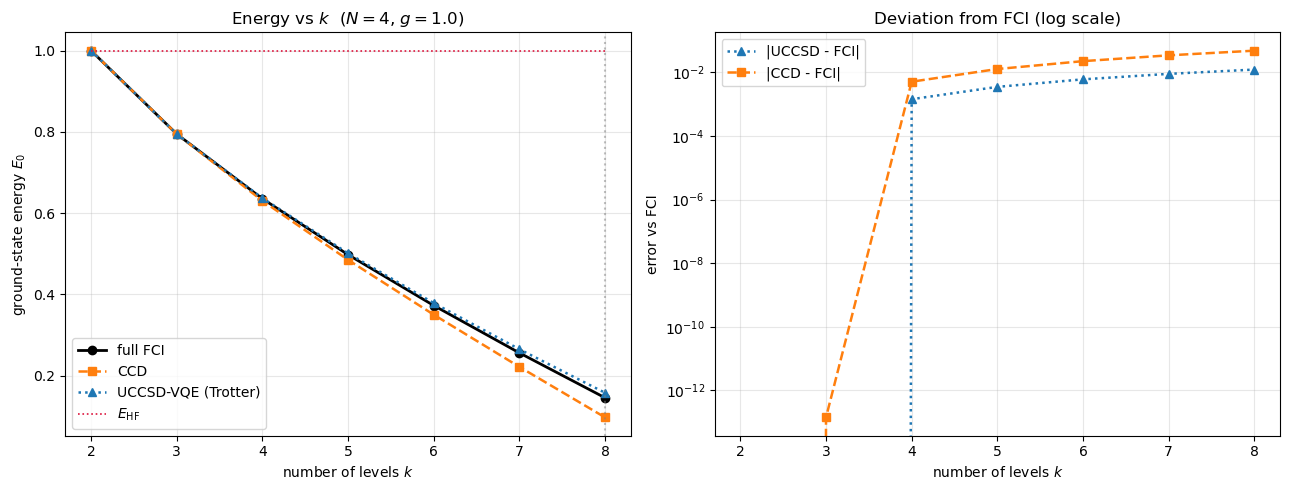

At k=8 (16 qubits): UCCSD-FCI = +1.23e-02,  CCD-FCI = -4.83e-02


In [7]:
ks_a   = np.array([r[0] for r in rows])
e_fci_a = np.array([r[3] for r in rows])
e_ccd_a = np.array([r[4] for r in rows])
e_u_a   = np.array([r[5] for r in rows])
E_HF_a  = np.array([E_HF(N, g) for _ in rows])

fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 5))
axL.plot(ks_a, e_fci_a, 'k-o', lw=2, label='full FCI')
axL.plot(ks_a, e_ccd_a, 'C1--s', lw=1.8, label='CCD')
axL.plot(ks_a, e_u_a, 'C0:^', lw=1.8, label='UCCSD-VQE (Trotter)')
axL.plot(ks_a, E_HF_a, color='crimson', ls=':', lw=1.2, label=r'$E_{\rm HF}$')
axL.axvline(8, color='gray', ls=':', alpha=0.5)
axL.set_xlabel('number of levels $k$'); axL.set_ylabel('ground-state energy $E_0$')
axL.set_title(f'Energy vs $k$  ($N={N}$, $g={g}$)'); axL.legend(); axL.grid(alpha=0.3)

axR.semilogy(ks_a, np.abs(e_u_a-e_fci_a), 'C0:^', lw=1.8, label='|UCCSD - FCI|')
axR.semilogy(ks_a, np.abs(e_ccd_a-e_fci_a), 'C1--s', lw=1.8, label='|CCD - FCI|')
axR.set_xlabel('number of levels $k$'); axR.set_ylabel('error vs FCI')
axR.set_title('Deviation from FCI (log scale)'); axR.legend(); axR.grid(alpha=0.3, which='both')
plt.tight_layout(); plt.show()
print(f"At k=8 (16 qubits): UCCSD-FCI = {e_u_a[-1]-e_fci_a[-1]:+.2e},  "
      f"CCD-FCI = {e_ccd_a[-1]-e_fci_a[-1]:+.2e}")

Both correlated methods recover most of the correlation energy.  UCCSD stays a
variational upper bound whose error grows slowly with $k$, while CCD (non-variational)
over-binds increasingly; at $k=8$ the UCCSD error ($\sim\!10^{-2}$) is several times
smaller in magnitude than the CCD error.

---
## 7  Effect of the number of Trotter steps

The product ansatz is a *first-order* Trotter approximation.  Repeating the product
$n_{\rm Trotter}$ times (each angle rescaled by $1/n_{\rm Trotter}$ and re-optimised)
tests whether Trotter error is significant.

In [8]:
k_t, N_t, g_t = 6, 4, 1.0
nq, states, index = build_sector(k_t, N_t)
H_t = H_pairing_sparse(k_t, g_t, N_t, states, index)
e_fci_t = fci_ground(H_t)
su_t = setup_uccsd(k_t, N_t)
print(f"Trotter-step convergence at k={k_t}, N={N_t}, g={g_t}   (FCI = {e_fci_t:.6f})")
print("-"*52)
for nt in (1, 2, 3):
    t0 = time.time(); e_u, _, _, _ = uccsd_vqe(su_t, H_t, n_trotter=nt)
    print(f"  n_Trotter = {nt}:  E_UCCSD = {e_u:.6f}   "
          f"E-FCI = {e_u-e_fci_t:+.2e}   ({time.time()-t0:.1f} s)")
print()
print("The energy is essentially flat in n_Trotter: first-order Trotter is already")
print("converged.  The residual gap to FCI is the singles-and-doubles *truncation*")
print("error of the ansatz, not a Trotter error.")

Trotter-step convergence at k=6, N=4, g=1.0   (FCI = 0.372664)
----------------------------------------------------
  n_Trotter = 1:  E_UCCSD = 0.378719   E-FCI = +6.06e-03   (0.5 s)
  n_Trotter = 2:  E_UCCSD = 0.378797   E-FCI = +6.13e-03   (1.4 s)
  n_Trotter = 3:  E_UCCSD = 0.378795   E-FCI = +6.13e-03   (3.1 s)

The energy is essentially flat in n_Trotter: first-order Trotter is already
converged.  The residual gap to FCI is the singles-and-doubles *truncation*
error of the ansatz, not a Trotter error.


  n_Trotter = 1:  E_UCCSD = 0.378719   E-FCI = +6.06e-03   (0.4 s)


  n_Trotter = 2:  E_UCCSD = 0.378797   E-FCI = +6.13e-03   (1.5 s)


  n_Trotter = 3:  E_UCCSD = 0.378795   E-FCI = +6.13e-03   (3.3 s)

The energy is essentially flat in n_Trotter: first-order Trotter is already
converged.  The residual gap to FCI is the singles-and-doubles *truncation*
error of the ansatz, not a Trotter error.


---
## 8  Varying the number of particles

The framework is not tied to $N=4$.  Here we fix $k=6$ and sweep the (even) particle
number $N=2,4,6,8$, comparing UCCSD–VQE with full FCI and CCD.

In [9]:
k_v, g_v = 6, 1.0
print(f"Varying N at k={k_v}, g={g_v}")
print("="*68)
print(f"  {'N':>2} {'pairs':>5} {'dimFCI':>7} {'FCI':>11} {'CCD':>11} {'UCCSD':>11} {'U-FCI':>9}")
print("  " + "-"*64)
for N_v in (2, 4, 6, 8):
    nq, states, index = build_sector(k_v, N_v)
    H_v = H_pairing_sparse(k_v, g_v, N_v, states, index)
    e_fci = fci_ground(H_v); e_ccd, _ = run_ccd(k_v, g_v, N_v)
    su = setup_uccsd(k_v, N_v); e_u, _, _, _ = uccsd_vqe(su, H_v)
    print(f"  {N_v:>2} {N_v//2:>5} {len(states):>7} {e_fci:>11.6f} {e_ccd:>11.6f} "
          f"{e_u:>11.6f} {e_u-e_fci:>+9.1e}")
print()
print("N=2 (one pair) is reproduced exactly; for N>=4 UCCSD is a tight upper bound.")

Varying N at k=6, g=1.0
   N pairs  dimFCI         FCI         CCD       UCCSD     U-FCI
  ----------------------------------------------------------------
   2     1      66   -0.906337   -0.906337   -0.906337  -2.2e-15
   4     2     495    0.372664    0.350058    0.378719  +6.1e-03
   6     3     924    3.801528    3.768061    3.809807  +8.3e-03
   8     4     495    9.372664    9.350058    9.378308  +5.6e-03

N=2 (one pair) is reproduced exactly; for N>=4 UCCSD is a tight upper bound.


   4     2     495    0.372664    0.350058    0.378719  +6.1e-03


   6     3     924    3.801528    3.768061    3.809807  +8.3e-03


   8     4     495    9.372664    9.350058    9.378308  +5.6e-03

N=2 (one pair) is reproduced exactly; for N>=4 UCCSD is a tight upper bound.


---
## 9  Dependence on the pairing strength $g$

Finally we sweep $g\in[0,1]$ at $k=6,\,N=4$ and overlay the three methods.

g-sweep done in 8.8 s


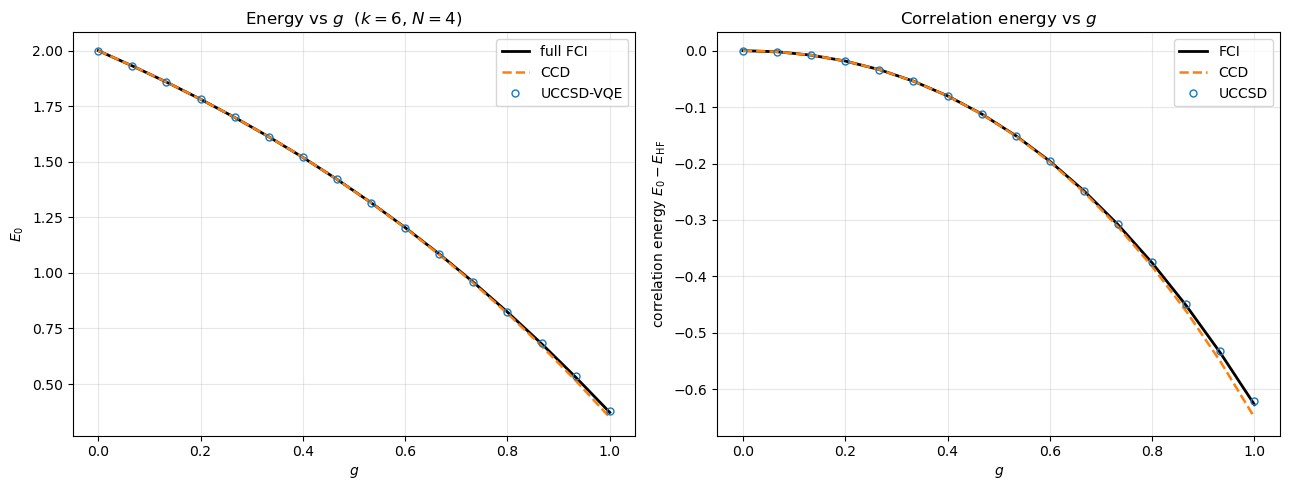

In [10]:
k_s, N_s = 6, 4
g_scan = np.linspace(0.0, 1.0, 16)
su_s = setup_uccsd(k_s, N_s)
E_fci_s, E_ccd_s, E_u_s = [], [], []
t0 = time.time()
for g in g_scan:
    nq, states, index = build_sector(k_s, N_s)
    H_s = H_pairing_sparse(k_s, g, N_s, states, index)
    E_fci_s.append(fci_ground(H_s))
    E_ccd_s.append(run_ccd(k_s, g, N_s)[0])
    E_u_s.append(uccsd_vqe(su_s, H_s)[0])
E_fci_s, E_ccd_s, E_u_s = map(np.array, (E_fci_s, E_ccd_s, E_u_s))
print(f"g-sweep done in {time.time()-t0:.1f} s")

fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 5))
axL.plot(g_scan, E_fci_s, 'k-', lw=2, label='full FCI')
axL.plot(g_scan, E_ccd_s, 'C1--', lw=1.8, label='CCD')
axL.plot(g_scan, E_u_s, 'C0o', ms=5, mfc='none', label='UCCSD-VQE')
axL.set_xlabel('$g$'); axL.set_ylabel('$E_0$')
axL.set_title(f'Energy vs $g$  ($k={k_s}$, $N={N_s}$)'); axL.legend(); axL.grid(alpha=0.3)

axR.plot(g_scan, E_fci_s-E_HF(N_s, g_scan), 'k-', lw=2, label='FCI')
axR.plot(g_scan, E_ccd_s-E_HF(N_s, g_scan), 'C1--', lw=1.8, label='CCD')
axR.plot(g_scan, E_u_s-E_HF(N_s, g_scan), 'C0o', ms=5, mfc='none', label='UCCSD')
axR.set_xlabel('$g$'); axR.set_ylabel(r'correlation energy $E_0-E_{\rm HF}$')
axR.set_title('Correlation energy vs $g$'); axR.legend(); axR.grid(alpha=0.3)
plt.tight_layout(); plt.show()

---
## 10  Summary

Starting from `pairing_uccsd_vqe.ipynb`, we added the Trotterised UCCSD implementation
of `qdresrefinement_vqe_K12_with_UCCSD.ipynb` and made the pairing model fully flexible:

* **Trotterisation.** The UCCSD unitary is a product of elementary
  $e^{\theta(\hat\tau-\hat\tau^\dagger)}$ factors, each realised as disjoint $2\times2$
  plane rotations on the Fock basis via precomputed $(I,J,s)$ tables — no dense matrix
  exponential.  A subtle point, improving on the second notebook: the simple two-term
  $\pi/4$ shift is exact only for the first factor acting on $|\Phi_{\rm HF}\rangle$;
  later factors introduce a frequency-1 component, so we use the exact product gradient
  (the generalised parameter-shift result), verified against finite differences.

* **Flexible $N$ and $k$.** Both the particle number and the number of levels are free.
  Working in the fixed-$N$ sector (dimension $\binom{2k}{N}$) lets us reach $k=8$
  (**16 qubits**) comfortably; we used $N=4$ as the running example and also varied
  $N=2,4,6,8$.

* **Full FCI comparison.** Every result is benchmarked against exact diagonalisation in
  the $N$-particle sector, which coincides with the seniority-zero result.

**Findings.** UCCSD–VQE is variational and tracks FCI closely, with an error that grows
slowly with $k$ (from $\sim\!10^{-3}$ at $k=4$ to $\sim\!10^{-2}$ at $k=8$), while CCD
over-binds with a larger-magnitude error. The Trotter-step study shows first-order
Trotter is already converged — the residual gap to FCI is the genuine
singles-and-doubles truncation error. The singles amplitudes vanish to machine
precision, confirming that the pairing correlations are carried entirely by the (pair)
doubles.